# Foodwaste Prediction

## Librerías 

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
%pip install holidays

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

IN_PATH = 'roca_nivaria_datos.xlsx'
TARGET = 'Desperdicio (kg)'



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## EDA

In [2]:
# Cargamos el dataset
df = pd.read_excel(IN_PATH, sheet_name='Adrián Hoteles')

# Añadimos una columna con la fecha en formato datetime
df['fecha'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Mostramos información básica del dataset
print(f"Tamaño dataset: {df.shape}")
print(f"Rango fechas: Desde {df['fecha'].min().date()} hasta {df['fecha'].max().date()}")
df.head()

Tamaño dataset: (15371, 20)
Rango fechas: Desde 2025-05-05 hasta 2026-07-01


,Date,turno,plato,% KG,% Reducción,% Reducción Total,_Tiene Datos,CO2,Comensales,Desperdicio (kg),Desviación %,KG Base,KG Evitados,KG Evitados Totales,kg/Comensal,KG Reales,Registros Procesados,Cobertura Comensales %,Cobertura Pesaje %,fecha
0,05/05/2025,DESAYUNO,Cereales,0.000024,0.774194,0.774194,1,1.75,616.0,0.70,16.907819,3.10,2.40,2.40,0.001136,0.70,1,1.0,1,2025-05-05
1,05/05/2025,DESAYUNO,Creps,0.000038,0.827316,0.827316,1,2.75,616.0,1.10,11.620748,6.37,5.27,5.27,0.001786,1.10,1,1.0,1,2025-05-05
2,05/05/2025,DESAYUNO,Croissant,0.000003,0.750000,0.750000,1,0.25,616.0,0.10,5.692821,0.40,0.30,0.30,0.000162,0.10,1,1.0,1,2025-05-05
3,05/05/2025,DESAYUNO,Dulces,0.000014,0.871166,0.871166,1,1.05,616.0,0.42,11.630295,3.26,2.84,2.84,0.000682,0.42,1,1.0,1,2025-05-05
4,05/05/2025,DESAYUNO,Embutidos,0.000024,0.916468,0.916468,1,1.75,616.0,0.70,1.967767,8.38,7.68,7.68,0.001136,0.70,1,1.0,1,2025-05-05


### Data Leakage

Varias columnas del export se calculan a partir del propio Desperdicio (kg) y no pueden usarse como feature ya que no estarán disponibles antes de que ocurra el desperdicio:

| Columna | Relación con el target |
|---|---|
| CO2 | = Desperdicio × 2.5 |
| KG Reales, % KG | correlación 1.0 |
| kg/Comensal | = Desperdicio / Comensales |
| KG Evitados | = max(0, KG Base − Desperdicio) |
| % Reducción, % Reducción Total | = KG Evitados / KG Base |
| Desviación % | derivada post-hoc del resultado del día |

In [3]:
LEAKAGE_COLS = [
    '% KG', 'CO2', 'KG Reales', 'kg/Comensal',
    'KG Evitados', 'KG Evitados Totales',
    '% Reducción', '% Reducción Total', 'Desviación %',
]

NO_VARIANCE_COLS = ['_Tiene Datos', 'Cobertura Pesaje %', 'Cobertura Comensales %']

corr = df[LEAKAGE_COLS + [TARGET]].corr()[TARGET].sort_values(ascending=False)
corr

CO2                    1.000000
KG Reales              1.000000
Desperdicio (kg)       1.000000
% KG                   1.000000
kg/Comensal            0.851421
KG Evitados            0.476616
KG Evitados Totales    0.476616
Desviación %           0.137447
% Reducción           -0.091524
% Reducción Total     -0.091524
Name: Desperdicio (kg), dtype: float64

### Visualización de datos

In [4]:
# Estadísticas principales
y = df[TARGET]
print(y.describe(percentiles=[.5, .75, .9, .95, .99]))
print(f"\nSkew: {y.skew():.2f} | Kurtosis: {y.kurt():.2f}")
print(f"Skew tras log1p: {np.log1p(y).skew():.2f}")

count    15371.000000
mean         1.902544
std          2.675781
min          0.020000
50%          1.180000
75%          2.080000
90%          4.090000
95%          6.170000
99%         11.440000
max        103.400000
Name: Desperdicio (kg), dtype: float64

Skew: 10.42 | Kurtosis: 278.00
Skew tras log1p: 1.15


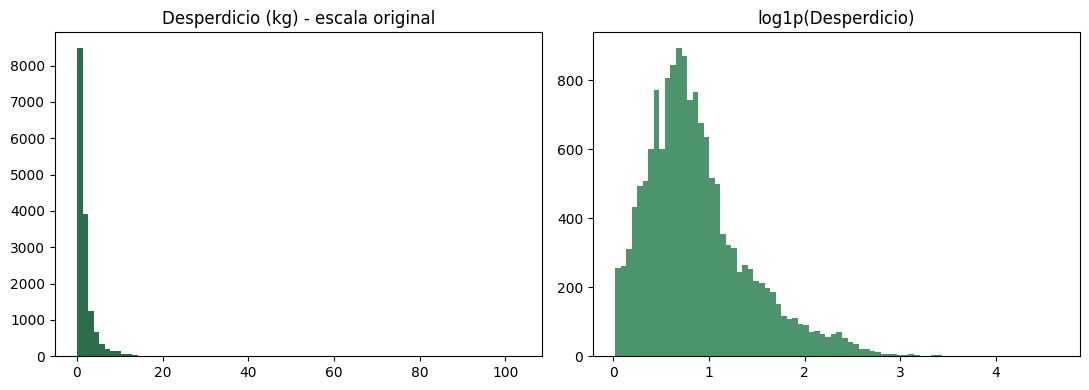

In [5]:
# Distribución de target
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(y, bins=80, color='#2C6E49')
axes[0].set_title('Desperdicio (kg) - escala original')
axes[1].hist(np.log1p(y), bins=80, color='#4C956C')
axes[1].set_title('log1p(Desperdicio)')
fig.tight_layout()
plt.show()

### Desperdicio por turno

           count      mean       std   min   25%   50%   75%     max
turno                                                               
ALMUERZO  3939.0  1.925169  2.959320  0.02  0.60  1.08  1.97   55.68
CENA      8368.0  1.945486  2.741327  0.02  0.70  1.24  2.16  103.40
DESAYUNO  3064.0  1.756181  2.028109  0.02  0.64  1.10  2.04   21.22


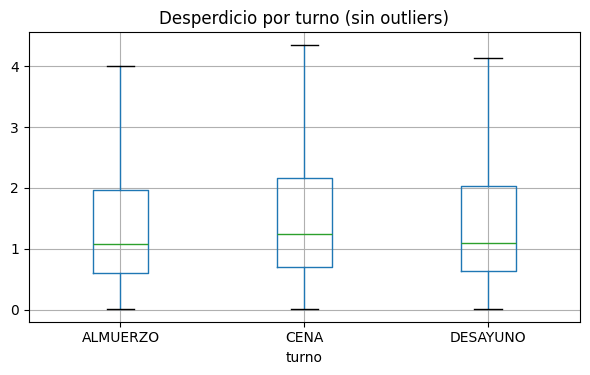

In [6]:
print(df.groupby('turno')[TARGET].describe())

fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column=TARGET, by='turno', ax=ax, showfliers=False)
ax.set_title('Desperdicio por turno (sin outliers)')
plt.suptitle('')
fig.tight_layout()
plt.show()

### Estacionalidad

     Desperdicio (kg)  Comensales
mes                              
1            2.378604  452.110727
2            1.537421  568.924528
3            1.668426  559.857763
4            1.551824  579.118586
5            2.023664  464.873119
6            1.859687  505.514003
7            2.026616  518.776169
8            1.866118  474.009317
9            1.928833  402.540292
10           2.077382  433.000000
11           1.820014  574.390756
12           1.745590  562.431204


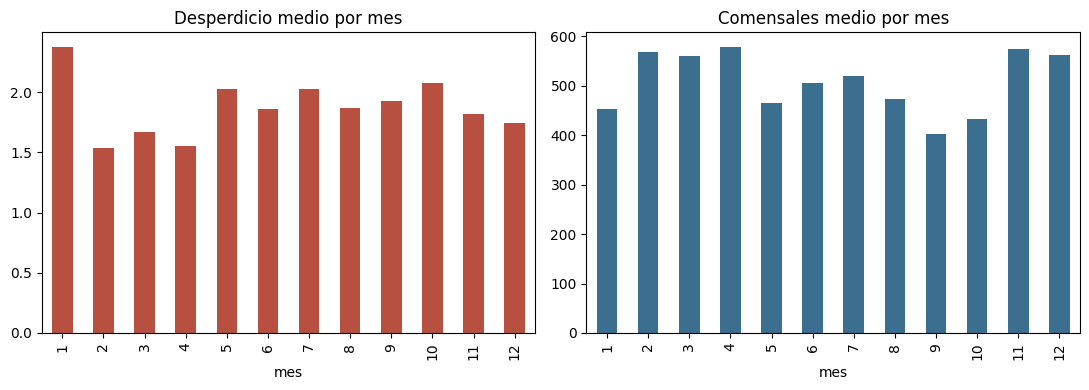

In [7]:
d = df.copy()
d['mes'] = d['fecha'].dt.month
d['dow'] = d['fecha'].dt.dayofweek
print(d.groupby('mes')[[TARGET, 'Comensales']].mean())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
d.groupby('mes')[TARGET].mean().plot(kind='bar', ax=axes[0], color='#B85042')
axes[0].set_title('Desperdicio medio por mes')
d.groupby('mes')['Comensales'].mean().plot(kind='bar', ax=axes[1], color='#3B6E8F')
axes[1].set_title('Comensales medio por mes')
fig.tight_layout()
plt.show()

### Desviación y medias por platos y turnos

In [8]:
g = df.groupby(['plato', 'turno'])[TARGET].agg(['mean', 'std', 'count'])
g = g[g['count'] >= 15].sort_values('mean', ascending=False)
print(g.head(15))

cnt = df.groupby(['plato', 'turno']).size()
print(f"\nCombinaciones plato+turno con <10 registros: {(cnt < 10).sum()} de {len(cnt)}")
print(f"Combinaciones plato+turno con <30 registros: {(cnt < 30).sum()} de {len(cnt)}")

                                                      mean        std  count
plato                                  turno                                
Comedor del personal                   ALMUERZO  15.520794  11.152498     63
Boles                                  CENA       7.506961   3.446638    283
                                       ALMUERZO   7.062323   3.050116    198
Zumos                                  DESAYUNO   6.424800   5.099333     25
Comedor del personal                   DESAYUNO   6.061000   3.866553    190
Desperdicio Cierre Buffet Niños        CENA       5.407177   3.316010    124
Comedor del personal                   CENA       5.121500   3.548772    140
Sopas y Cremas                         ALMUERZO   4.818857   1.347844    105
                                       CENA       4.764494   3.104943    267
Desperdicio de Reposición Buffet Niños CENA       4.512667   2.357939     15
Verdura Frío Desayuno                  DESAYUNO   3.570000   4.776360     18

### Valores faltantes

In [9]:
print(df.isna().sum()[df.isna().sum() > 0])

missing_dates = df[df['Comensales'].isna()][['fecha', 'turno']].drop_duplicates()
print(f"\nComensales falta en {missing_dates['fecha'].nunique()} fechas completas (servicios enteros sin registrar, no aleatorio):")
print(missing_dates.sort_values('fecha').to_string(index=False))

% Reducción                78
% Reducción Total          78
Comensales                350
Desviación %              350
KG Base                    78
KG Evitados                78
KG Evitados Totales        78
kg/Comensal               350
Cobertura Comensales %    350
dtype: int64

Comensales falta en 9 fechas completas (servicios enteros sin registrar, no aleatorio):
     fecha    turno
2025-06-04 DESAYUNO
2025-06-04 ALMUERZO
2025-06-04     CENA
2025-07-19 DESAYUNO
2025-07-19 ALMUERZO
2025-07-19     CENA
2025-10-16 ALMUERZO
2025-10-16     CENA
2025-10-19 DESAYUNO
2025-10-19 ALMUERZO
2025-10-19     CENA
2026-06-01     CENA
2026-06-01 ALMUERZO
2026-06-01 DESAYUNO
2026-06-02 DESAYUNO
2026-06-02 ALMUERZO
2026-06-02     CENA
2026-06-03 DESAYUNO
2026-06-03 ALMUERZO
2026-06-03     CENA
2026-06-04 DESAYUNO
2026-06-04 ALMUERZO
2026-06-04     CENA
2026-06-05 DESAYUNO
2026-06-05 ALMUERZO


### Kg base estandar

In [10]:
nun = df.groupby(['plato', 'turno'])['KG Base'].nunique()
print(f"KG Base es constante dentro de (plato,turno) en {(nun == 1).sum()} de {len(nun)} casos.")
print(f"({(nun == 0).sum()} combinaciones no tienen ningún valor -> platos nuevos sin referencia configurada aún)")
print(f"Correlación KG Base vs target: {df[['KG Base', TARGET]].corr().iloc[0, 1]:.3f}")

KG Base es constante dentro de (plato,turno) en 339 de 383 casos.
(44 combinaciones no tienen ningún valor -> platos nuevos sin referencia configurada aún)
Correlación KG Base vs target: 0.513


## Preprocesamiento

In [11]:
def load_raw(path):
    df = pd.read_excel(path, sheet_name='Adrián Hoteles')
    df['fecha'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
    df = df.drop(columns=['Date'] + LEAKAGE_COLS + NO_VARIANCE_COLS)
    df = df.sort_values(['fecha', 'turno', 'plato']).reset_index(drop=True)
    return df

### Feature de calendario

In [12]:
def add_calendar_features(df):
    df['anio'] = df['fecha'].dt.year
    df['mes'] = df['fecha'].dt.month
    df['dia_semana'] = df['fecha'].dt.dayofweek  # 0=lunes
    df['es_finde'] = df['dia_semana'].isin([5, 6]).astype(int)
    df['dia_mes'] = df['fecha'].dt.day
    df['semana_anio'] = df['fecha'].dt.isocalendar().week.astype(int)
    return df

### Imputación

`Comensales` falta en servicios enteros -> mediana por turno + día de semana.
`KG Base` falta en platos nuevos/raros -> mediana por turno. Ambas con flag de imputación.

In [13]:
def impute_comensales(df):
    df['comensales_imputado'] = df['Comensales'].isna().astype(int)
    fallback = df.groupby(['turno', 'dia_semana'])['Comensales'].transform('median')
    df['Comensales'] = df['Comensales'].fillna(fallback)
    fallback_turno = df.groupby('turno')['Comensales'].transform('median')
    df['Comensales'] = df['Comensales'].fillna(fallback_turno)
    return df


def impute_kg_base(df):
    df['kg_base_imputado'] = df['KG Base'].isna().astype(int)
    fallback = df.groupby('turno')['KG Base'].transform('median')
    df['KG Base'] = df['KG Base'].fillna(fallback)
    return df

### Feature históricas casuales

In [27]:
def add_historical_features(df):

    df = df.sort_values(["plato", "turno", "fecha"]).copy()

    grupo = df.groupby(["plato", "turno"])

    # Nº observaciones previas
    df["hist_n_obs"] = grupo.cumcount()

    # LAGS
    for lag in [1, 7, 14, 28]:
        df[f"hist_lag{lag}"] = grupo[TARGET].shift(lag)

    # MEDIA EXPANDIDA
    df["hist_media_expandida"] = (
        grupo[TARGET]
        .transform(lambda x: x.shift(1).expanding().mean())
    )

    # STD EXPANDIDA
    df["hist_std_expandida"] = (
        grupo[TARGET]
        .transform(lambda x: x.shift(1).expanding().std())
    )

    # MEDIAS MÓVILES
    for w in [3, 5, 7, 14, 28]:

        df[f"hist_media_movil_{w}"] = (
            grupo[TARGET]
            .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
        )

    # STD MÓVIL
    for w in [7, 14]:

        df[f"hist_std_{w}"] = (
            grupo[TARGET]
            .transform(lambda x: x.shift(1).rolling(w, min_periods=2).std())
        )

    # TENDENCIA
    df["hist_tendencia"] = (
        df["hist_media_movil_7"]
        - df["hist_media_movil_28"]
    )

    return df

def encode_categoricals(df, categorical_cols=None):

    df = df.copy()

    if categorical_cols is None:
        categorical_cols = ["turno", "plato"]

    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype("category")

    return df

### Variables de calendario avanzadas

In [15]:
try:
    import holidays
except ImportError:
    holidays = None


def add_advanced_calendar_features(df, fecha_col='fecha'):
    # Añade variables de calendario derivadas automáticamente de la fecha.
    df = df.copy()
    df[fecha_col] = pd.to_datetime(df[fecha_col])

    years = sorted(df[fecha_col].dt.year.unique())

    if holidays is not None:
        festivos_es = holidays.Spain(years=years)
        festivos_cn = holidays.Spain(subdiv='CN', years=years)
        festivos = set(festivos_es.keys()) | set(festivos_cn.keys())
        festivos = pd.to_datetime(list(festivos))
    else:
        print('Aviso: librería holidays no instalada. Las variables de festivos se rellenan con 0.')
        festivos = pd.to_datetime([])

    df['es_festivo'] = df[fecha_col].isin(festivos).astype(int)

    festivos_previos = festivos - pd.Timedelta(days=1)
    festivos_posteriores = festivos + pd.Timedelta(days=1)

    df['vispera_festivo'] = df[fecha_col].isin(festivos_previos).astype(int)
    df['dia_post_festivo'] = df[fecha_col].isin(festivos_posteriores).astype(int)

    es_lunes = df[fecha_col].dt.dayofweek == 0
    es_viernes = df[fecha_col].dt.dayofweek == 4
    festivo_manana = df[fecha_col].add(pd.Timedelta(days=1)).isin(festivos)
    festivo_ayer = df[fecha_col].sub(pd.Timedelta(days=1)).isin(festivos)

    df['es_puente'] = ((es_lunes & festivo_ayer) | (es_viernes & festivo_manana) | (festivo_ayer & festivo_manana)).astype(int)

    mes = df[fecha_col].dt.month
    dia = df[fecha_col].dt.day

    df['vacaciones_escolares'] = (
        mes.isin([7, 8]) |
        ((mes == 12) & (dia >= 20)) |
        ((mes == 1) & (dia <= 7)) |
        ((mes == 4) & (dia.between(1, 15)))
    ).astype(int)

    conditions = [
        mes.isin([7, 8, 12]),
        mes.isin([3, 4, 5, 6, 9, 10, 11]),
        mes.isin([1, 2]),
    ]
    choices = ['alta', 'media', 'baja']

    df['temporada_turistica'] = np.select(conditions, choices, default='media')
    df['temporada_alta'] = (df['temporada_turistica'] == 'alta').astype(int)

    # Variable preparada para sustituirse por una tabla real de eventos locales.
    df['evento_local'] = 0

    return df


calendar_extra_cols = [
    'es_festivo',
    'vispera_festivo',
    'dia_post_festivo',
    'es_puente',
    'vacaciones_escolares',
    'temporada_turistica',
    'temporada_alta',
    'evento_local',
]


### Variables temporales derivadas

In [16]:
def add_temporal_features(df, fecha_col='fecha'):
    # Añade variables temporales y cíclicas derivadas automáticamente de la fecha.
    df = df.copy()
    df[fecha_col] = pd.to_datetime(df[fecha_col])

    df['inicio_mes'] = (df[fecha_col].dt.day <= 5).astype(int)
    df['fin_mes'] = (df[fecha_col].dt.day >= 25).astype(int)
    df['inicio_semana'] = (df[fecha_col].dt.dayofweek <= 1).astype(int)
    df['fin_semana'] = (df[fecha_col].dt.dayofweek >= 5).astype(int)

    df['mes_sin'] = np.sin(2 * np.pi * df[fecha_col].dt.month / 12)
    df['mes_cos'] = np.cos(2 * np.pi * df[fecha_col].dt.month / 12)
    df['dia_semana_sin'] = np.sin(2 * np.pi * df[fecha_col].dt.dayofweek / 7)
    df['dia_semana_cos'] = np.cos(2 * np.pi * df[fecha_col].dt.dayofweek / 7)

    df['dia_anio'] = df[fecha_col].dt.dayofyear
    df['dia_anio_sin'] = np.sin(2 * np.pi * df['dia_anio'] / 365)
    df['dia_anio_cos'] = np.cos(2 * np.pi * df['dia_anio'] / 365)

    if 'es_festivo' in df.columns:
        festivos = df.loc[df['es_festivo'] == 1, fecha_col].drop_duplicates().sort_values()
    else:
        festivos = pd.Series([], dtype='datetime64[ns]')

    if len(festivos) > 0:
        fechas = df[fecha_col]
        df['dias_desde_ultimo_festivo'] = fechas.apply(
            lambda x: (x - festivos[festivos <= x].max()).days if len(festivos[festivos <= x]) > 0 else 999
        )
        df['dias_hasta_proximo_festivo'] = fechas.apply(
            lambda x: (festivos[festivos >= x].min() - x).days if len(festivos[festivos >= x]) > 0 else 999
        )
    else:
        df['dias_desde_ultimo_festivo'] = 999
        df['dias_hasta_proximo_festivo'] = 999

    return df


temporal_extra_cols = [
    'inicio_mes',
    'fin_mes',
    'inicio_semana',
    'fin_semana',
    'mes_sin',
    'mes_cos',
    'dia_semana_sin',
    'dia_semana_cos',
    'dia_anio',
    'dia_anio_sin',
    'dia_anio_cos',
    'dias_desde_ultimo_festivo',
    'dias_hasta_proximo_festivo',
]


### Variables meteorológicas automáticas

In [17]:
LATITUDE = 28.1227      # Coordenada aproximada Tenerife sur. Sustituir por la ubicación real del hotel.
LONGITUDE = -16.7260    # Coordenada aproximada Tenerife sur. Sustituir por la ubicación real del hotel.
USE_WEATHER_FEATURES = True


def get_weather_features_from_open_meteo(df, fecha_col='fecha', latitude=LATITUDE, longitude=LONGITUDE):
    # Descarga meteorología histórica de Open-Meteo y la cruza por fecha.
    # Si la API no está disponible, crea las columnas meteorológicas en NaN/0 y no rompe el notebook.
    df = df.copy()
    df[fecha_col] = pd.to_datetime(df[fecha_col])

    start_date = df[fecha_col].min().strftime('%Y-%m-%d')
    end_date = df[fecha_col].max().strftime('%Y-%m-%d')

    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude': latitude,
        'longitude': longitude,
        'start_date': start_date,
        'end_date': end_date,
        'daily': [
            'temperature_2m_mean',
            'temperature_2m_max',
            'temperature_2m_min',
            'precipitation_sum',
            'wind_speed_10m_max',
        ],
        'hourly': ['relative_humidity_2m'],
        'timezone': 'Europe/Madrid',
    }

    try:
        response = requests.get(url, params=params, timeout=60)
        response.raise_for_status()
        data = response.json()

        weather_daily = pd.DataFrame(data['daily'])
        weather_daily['fecha'] = pd.to_datetime(weather_daily['time'])
        weather_daily = weather_daily.drop(columns=['time'])
        weather_daily = weather_daily.rename(columns={
            'temperature_2m_mean': 'temperatura_media',
            'temperature_2m_max': 'temperatura_max',
            'temperature_2m_min': 'temperatura_min',
            'precipitation_sum': 'precipitacion_mm',
            'wind_speed_10m_max': 'viento_kmh',
        })

        if 'hourly' in data and 'relative_humidity_2m' in data['hourly']:
            weather_hourly = pd.DataFrame(data['hourly'])
            weather_hourly['fecha'] = pd.to_datetime(weather_hourly['time']).dt.date
            weather_hourly['fecha'] = pd.to_datetime(weather_hourly['fecha'])
            humedad = (
                weather_hourly
                .groupby('fecha')['relative_humidity_2m']
                .mean()
                .reset_index()
                .rename(columns={'relative_humidity_2m': 'humedad_relativa'})
            )
            weather = weather_daily.merge(humedad, on='fecha', how='left')
        else:
            weather = weather_daily.copy()
            weather['humedad_relativa'] = np.nan

        weather['lluvia'] = (weather['precipitacion_mm'] > 0).astype(int)
        weather['dia_lluvioso'] = (weather['precipitacion_mm'] >= 1).astype(int)
        weather['dia_caluroso'] = (weather['temperatura_max'] >= 30).astype(int)
        weather['calima'] = 0  # pendiente de integración externa específica

        df = df.merge(weather, on='fecha', how='left')

    except Exception as exc:
        print(f'Aviso: no se pudo obtener meteorología de Open-Meteo: {exc}')
        for col in weather_cols:
            if col not in df.columns:
                df[col] = 0 if col in ['lluvia', 'dia_lluvioso', 'dia_caluroso', 'calima'] else np.nan

    return df


weather_cols = [
    'temperatura_media',
    'temperatura_max',
    'temperatura_min',
    'precipitacion_mm',
    'lluvia',
    'dia_lluvioso',
    'dia_caluroso',
    'viento_kmh',
    'humedad_relativa',
    'calima',
]


### Lista de variables históricas

In [18]:
historical_cols = [
    "hist_n_obs",

    "hist_lag1",
    "hist_lag7",
    "hist_lag14",
    "hist_lag28",

    "hist_media_expandida",

    "hist_media_movil_3",
    "hist_media_movil_5",
    "hist_media_movil_7",
    "hist_media_movil_14",
    "hist_media_movil_28",

    "hist_std_expandida",
    "hist_std_7",
    "hist_std_14",

    "hist_tendencia"
]

## Split temporal

In [19]:
def temporal_train_val_test_split(df, val_fraction_days=0.15, test_fraction_days=0.15):
    dates = np.sort(df["fecha"].unique())
    n_dates = len(dates)

    test_start_idx = int(n_dates * (1 - test_fraction_days))
    val_start_idx = int(n_dates * (1 - test_fraction_days - val_fraction_days))

    val_start_date = dates[val_start_idx]
    test_start_date = dates[test_start_idx]

    train = df[df["fecha"] < val_start_date].copy()
    val = df[
        (df["fecha"] >= val_start_date)
        & (df["fecha"] < test_start_date)
    ].copy()
    test = df[df["fecha"] >= test_start_date].copy()

    return (
        train,
        val,
        test,
        str(pd.Timestamp(val_start_date).date()),
        str(pd.Timestamp(test_start_date).date()),
    )

## Entrenamiento modelo CatBoost

## Dataset de modelado

A partir de aquí se construye `df_p`, que es el dataset que entra al modelo. Cada transformación queda separada para que sea fácil auditar qué se está añadiendo.

In [20]:
df_p = load_raw(IN_PATH)

_df_steps = []

df_p = add_calendar_features(df_p)
_df_steps.append(('calendar_features', df_p.shape))

df_p = add_advanced_calendar_features(df_p)
_df_steps.append(('advanced_calendar_features', df_p.shape))

df_p = add_temporal_features(df_p)
_df_steps.append(('temporal_features', df_p.shape))

if USE_WEATHER_FEATURES:
    df_p = get_weather_features_from_open_meteo(df_p)
    _df_steps.append(('weather_features', df_p.shape))
else:
    for col in weather_cols:
        if col not in df_p.columns:
            df_p[col] = 0 if col in ['lluvia', 'dia_lluvioso', 'dia_caluroso', 'calima'] else np.nan
    _df_steps.append(('weather_features_disabled', df_p.shape))

pd.DataFrame(_df_steps, columns=['paso', 'shape'])


,paso,shape
0,calendar_features,"(15371, 13)"
1,advanced_calendar_features,"(15371, 21)"
2,temporal_features,"(15371, 34)"
3,weather_features,"(15371, 44)"


In [21]:
df_p = impute_comensales(df_p)
df_p = impute_kg_base(df_p)

print('NaNs tras imputación básica:')
display(df_p[['Comensales', 'KG Base', 'comensales_imputado', 'kg_base_imputado']].isna().sum())


NaNs tras imputación básica:


Comensales             0
KG Base                0
comensales_imputado    0
kg_base_imputado       0
dtype: int64

In [22]:
df_p = add_historical_features(df_p)

print('Variables históricas generadas:')
display(df_p[historical_cols].head())


Variables históricas generadas:


,hist_n_obs,hist_lag1,hist_lag7,hist_lag14,hist_lag28,hist_media_expandida,hist_media_movil_3,hist_media_movil_5,hist_media_movil_7,hist_media_movil_14,hist_media_movil_28,hist_std_expandida,hist_std_7,hist_std_14,hist_tendencia
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,1,1.94,NaN,NaN,NaN,1.9400,1.94,1.9400,1.9400,1.9400,1.9400,NaN,NaN,NaN,0.0
734,2,2.74,NaN,NaN,NaN,2.3400,2.34,2.3400,2.3400,2.3400,2.3400,0.565685,0.565685,0.565685,0.0
1157,3,1.65,NaN,NaN,NaN,2.1100,2.11,2.1100,2.1100,2.1100,2.1100,0.564535,0.564535,0.564535,0.0
1893,4,2.24,NaN,NaN,NaN,2.1425,2.21,2.1425,2.1425,2.1425,2.1425,0.465502,0.465502,0.465502,0.0


In [28]:
cat_features = ['turno', 'plato', 'temporada_turistica']
cat_features = [col for col in cat_features if col in df_p.columns]

df_p = encode_categoricals(df_p, categorical_cols=cat_features)
df_p['log_target'] = np.log1p(df_p[TARGET])

print('Variables categóricas:', cat_features)
print('Shape final df_p:', df_p.shape)
df_p.head()


Variables categóricas: ['turno', 'plato', 'temporada_turistica']
Shape final df_p: (15371, 62)


,turno,plato,Comensales,Desperdicio (kg),KG Base,Registros Procesados,fecha,anio,mes,dia_semana,es_finde,dia_mes,semana_anio,es_festivo,vispera_festivo,dia_post_festivo,es_puente,vacaciones_escolares,temporada_turistica,temporada_alta,evento_local,inicio_mes,fin_mes,inicio_semana,fin_semana,...,precipitacion_mm,viento_kmh,humedad_relativa,lluvia,dia_lluvioso,dia_caluroso,calima,comensales_imputado,kg_base_imputado,hist_n_obs,hist_lag1,hist_lag7,hist_lag14,hist_lag28,hist_media_expandida,hist_std_expandida,hist_media_movil_3,hist_media_movil_5,hist_media_movil_7,hist_media_movil_14,hist_media_movil_28,hist_std_7,hist_std_14,hist_tendencia,log_target
0,ALMUERZO,Abadejo al horno,237.0,1.94,8.26,1,2025-05-05,2025,5,0,0,5,19,0,0,0,0,0,media,0,0,1,0,1,0,...,0.0,10.0,71.875000,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.078410
362,ALMUERZO,Abadejo al horno,169.0,2.74,8.26,1,2025-05-12,2025,5,0,0,12,20,0,0,0,0,0,media,0,0,0,0,1,0,...,0.0,12.6,77.458333,0,0,0,0,0,0,1,1.94,NaN,NaN,NaN,1.9400,NaN,1.94,1.9400,1.9400,1.9400,1.9400,NaN,NaN,0.0,1.319086
734,ALMUERZO,Abadejo al horno,180.0,1.65,8.26,1,2025-05-19,2025,5,0,0,19,21,0,0,0,0,0,media,0,0,0,0,1,0,...,0.0,9.3,68.041667,0,0,0,0,0,0,2,2.74,NaN,NaN,NaN,2.3400,0.565685,2.34,2.3400,2.3400,2.3400,2.3400,0.565685,0.565685,0.0,0.974560
1157,ALMUERZO,Abadejo al horno,251.0,2.24,8.26,1,2025-05-26,2025,5,0,0,26,22,0,0,0,0,0,media,0,0,0,1,1,0,...,0.0,5.1,65.291667,0,0,0,0,0,0,3,1.65,NaN,NaN,NaN,2.1100,0.564535,2.11,2.1100,2.1100,2.1100,2.1100,0.564535,0.564535,0.0,1.175573
1893,ALMUERZO,Abadejo al horno,266.0,3.60,8.26,1,2025-06-09,2025,6,0,0,9,24,0,0,0,0,0,media,0,0,0,0,1,0,...,0.0,11.3,60.083333,0,0,0,0,0,0,4,2.24,NaN,NaN,NaN,2.1425,0.465502,2.21,2.1425,2.1425,2.1425,2.1425,0.465502,0.465502,0.0,1.526056


## Definición de variables del modelo

Se centraliza la lista de features para evitar duplicidades y asegurar que `FEATURE_COLS` y `cat_features` estén sincronizados.

In [29]:
base_feature_cols = [
    'turno',
    'plato',
    'Comensales',
    'KG Base',
    'anio',
    'mes',
    'dia_semana',
    'es_finde',
    'dia_mes',
    'semana_anio',
    'comensales_imputado',
    'kg_base_imputado',
]

candidate_feature_cols = base_feature_cols + historical_cols + calendar_extra_cols + temporal_extra_cols + weather_cols

FEATURE_COLS = []
for col in candidate_feature_cols:
    if col in df_p.columns and col not in FEATURE_COLS:
        FEATURE_COLS.append(col)

cat_features = [col for col in cat_features if col in FEATURE_COLS]

print('N features:', len(FEATURE_COLS))
print('Categorical features:', cat_features)
display(pd.DataFrame({'feature': FEATURE_COLS}))


N features: 58
Categorical features: ['turno', 'plato', 'temporada_turistica']


,feature
0,turno
1,plato
2,Comensales
3,KG Base
4,anio
5,mes
6,dia_semana
7,es_finde
8,dia_mes
9,semana_anio


## Funciones para tuning temporal

Estas funciones solo preparan los splits de validación temporal y buscan hiperparámetros. No entrenan el modelo final.

In [30]:
def build_time_series_splits(df, n_splits=3, test_fraction=0.15):
    dates = np.sort(df['fecha'].unique())
    n_dates = len(dates)
    test_start = int(n_dates * (1 - test_fraction))
    train_dates = dates[:test_start]
    final_test_dates = dates[test_start:]

    if len(train_dates) <= n_splits:
        raise ValueError('No hay suficientes fechas para los splits temporales solicitados.')

    splits = []
    tscv = TimeSeriesSplit(n_splits=n_splits)
    for train_idx, val_idx in tscv.split(train_dates):
        train_mask = df['fecha'].isin(train_dates[train_idx])
        val_mask = df['fecha'].isin(train_dates[val_idx])
        test_mask = df['fecha'].isin(final_test_dates)
        splits.append((train_mask, val_mask, test_mask))

    return splits


def tune_catboost_params(df, feature_cols, cat_features, splits, param_grid):
    best_score = np.inf
    best_params = None
    tuning_rows = []

    for params in ParameterGrid(param_grid):
        fold_scores = []
        for fold_id, (train_mask, val_mask, _) in enumerate(splits, start=1):
            train_fold = df[train_mask]
            val_fold = df[val_mask]

            train_pool = Pool(data=train_fold[feature_cols], label=train_fold['log_target'], cat_features=cat_features)
            val_pool = Pool(data=val_fold[feature_cols], label=val_fold['log_target'], cat_features=cat_features)

            tmp_model = CatBoostRegressor(
                iterations=500,
                learning_rate=params['learning_rate'],
                depth=params['depth'],
                l2_leaf_reg=params['l2_leaf_reg'],
                random_strength=1,
                bagging_temperature=params['bagging_temperature'],
                loss_function='RMSE',
                eval_metric='RMSE',
                random_seed=42,
                early_stopping_rounds=50,
                min_data_in_leaf=params['min_data_in_leaf'],
                verbose=0,
            )

            tmp_model.fit(train_pool, eval_set=val_pool, use_best_model=True)
            pred_val = tmp_model.predict(val_pool)
            fold_rmse = np.sqrt(np.mean((val_fold['log_target'].values - pred_val) ** 2))
            fold_scores.append(fold_rmse)

        mean_score = np.mean(fold_scores)
        tuning_rows.append({**params, 'rmse_log_cv': mean_score})

        if mean_score < best_score:
            best_score = mean_score
            best_params = params

    tuning_results = pd.DataFrame(tuning_rows).sort_values('rmse_log_cv').reset_index(drop=True)
    return best_params, best_score, tuning_results


In [31]:
splits = build_time_series_splits(df_p, n_splits=3, test_fraction=0.15)

param_grid = {
    'depth': [6, 8, 10],
    'learning_rate': [0.01, 0.02, 0.05],
    'l2_leaf_reg': [3, 5, 7],
    'bagging_temperature': [0.2, 0.5, 1.0],
    'min_data_in_leaf': [10, 20, 30],
}

best_params, best_score, tuning_results = tune_catboost_params(df_p, FEATURE_COLS, cat_features, splits, param_grid)

print('Mejor RMSE en log-target (val folds):', best_score)
print('Mejores parámetros encontrados:', best_params)
display(tuning_results.head(10))


KeyboardInterrupt: 

## Split final Train / Validation / Test

Este split es independiente del tuning. Se usa para entrenar el modelo final y evaluar el rendimiento real en test.

In [ ]:
train, val, test, val_start, test_start = temporal_train_val_test_split(
    df_p,
    val_fraction_days=0.15,
    test_fraction_days=0.15,
)

print(f'Train: {train.shape} | Val: {val.shape} | Test: {test.shape}')
print(f'Inicio validación: {val_start} | Inicio test final: {test_start}')


In [ ]:
nan_summary = pd.DataFrame({
    'train': train[FEATURE_COLS].isna().sum(),
    'val': val[FEATURE_COLS].isna().sum(),
    'test': test[FEATURE_COLS].isna().sum(),
})

nan_summary = nan_summary[nan_summary.sum(axis=1) > 0]

print(f'NaNs totales en features train: {train[FEATURE_COLS].isna().sum().sum()}')
print(f'NaNs totales en features val:   {val[FEATURE_COLS].isna().sum().sum()}')
print(f'NaNs totales en features test:  {test[FEATURE_COLS].isna().sum().sum()}')

display(nan_summary)
train[FEATURE_COLS + [TARGET, 'log_target']].head(20)


## Pools de CatBoost

Se crean los `Pool` una sola vez para train, validation y test.

In [ ]:
train_pool = Pool(data=train[FEATURE_COLS], label=train['log_target'], cat_features=cat_features)
val_pool = Pool(data=val[FEATURE_COLS], label=val['log_target'], cat_features=cat_features)
test_pool = Pool(data=test[FEATURE_COLS], label=test['log_target'], cat_features=cat_features)


In [ ]:
final_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=best_params['learning_rate'],
    depth=best_params['depth'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    bagging_temperature=best_params['bagging_temperature'],
    min_data_in_leaf=best_params['min_data_in_leaf'],
    random_strength=1,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=100,
    verbose=100,
)

final_model.fit(train_pool, eval_set=val_pool, use_best_model=True)


In [ ]:
pred_log = final_model.predict(test_pool)

test = test.copy()
test['pred_log'] = pred_log
test['pred_kg'] = np.expm1(pred_log).clip(min=0)
test['error_kg'] = test['pred_kg'] - test[TARGET]
test['abs_error_kg'] = test['error_kg'].abs()

test[[TARGET, 'pred_kg', 'error_kg', 'abs_error_kg']].head(20)


## Manifest para reproducibilidad

In [ ]:
os.makedirs("processed", exist_ok=True)

train.to_csv("processed/train.csv", index=False)
val.to_csv("processed/val.csv", index=False)
test.to_csv("processed/test.csv", index=False)

manifest = {
    "target": TARGET,
    "target_log": "log_target (log1p)",
    "cutoff_date_train_val": str(val_start),
    "cutoff_date_val_test": str(test_start),
    "n_train": len(train),
    "n_val": len(val),
    "n_test": len(test),
    "feature_cols": FEATURE_COLS,
    "categorical_cols": ["turno", "plato"],
    "dropped_leakage_cols": LEAKAGE_COLS,
    "dropped_no_variance_cols": NO_VARIANCE_COLS,
    "best_params": best_params,
    "cv_rmse_log": float(best_score),
}

with open("processed/manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print("Guardado en ./processed/")

## Evaluación

In [ ]:
def evaluar_modelo(y_true, y_pred, nombre="Modelo"):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    abs_error = np.abs(y_true - y_pred)

    # MAPE: solo se calcula donde el valor real es mayor que 0
    mask = y_true > 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    # sMAPE
    smape = (
        np.mean(
            2 * np.abs(y_pred - y_true)
            / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
        )
        * 100
    )

    # WAPE
    total_real = np.sum(np.abs(y_true))
    if total_real > 0:
        wape = np.sum(abs_error) / total_real * 100
    else:
        wape = np.nan

    # Sesgo: positivo = sobreestima; negativo = infraestima
    bias = np.mean(y_pred - y_true)

    # MAE relativo respecto al desperdicio medio real
    mean_real = np.mean(y_true)
    if mean_real > 0:
        mae_relativo = mae / mean_real * 100
    else:
        mae_relativo = np.nan

    # Percentiles del error absoluto
    p50 = np.percentile(abs_error, 50)
    p75 = np.percentile(abs_error, 75)
    p90 = np.percentile(abs_error, 90)
    p95 = np.percentile(abs_error, 95)
    max_error = np.max(abs_error)

    print(f"\n===== {nombre} =====")
    print(f"N muestras   : {n}")
    print(f"MAE          : {mae:.3f} kg")
    print(f"RMSE         : {rmse:.3f} kg")
    print(f"R²           : {r2:.3f}")
    print(f"Bias         : {bias:.3f} kg")
    print(f"MAE relativo : {mae_relativo:.2f} %")
    print(f"MAPE         : {mape:.2f} %")
    print(f"sMAPE        : {smape:.2f} %")
    print(f"WAPE         : {wape:.2f} %")

    print("\nDistribución del error absoluto")
    print(f"P50          : {p50:.3f} kg")
    print(f"P75          : {p75:.3f} kg")
    print(f"P90          : {p90:.3f} kg")
    print(f"P95          : {p95:.3f} kg")
    print(f"Máximo error : {max_error:.3f} kg")

    return {
        "Nombre": nombre,
        "N": n,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Bias": bias,
        "MAE_relativo_%": mae_relativo,
        "MAPE": mape,
        "sMAPE": smape,
        "WAPE": wape,
        "P50": p50,
        "P75": p75,
        "P90": p90,
        "P95": p95,
        "MaxError": max_error,
    }

In [ ]:
metricas_test = evaluar_modelo(
    y_true=test[TARGET],
    y_pred=test["pred_kg"],
    nombre="CatBoost final - Test"
)

### Importancia de las variables

In [ ]:
importance = (
    pd.DataFrame({
        "feature": FEATURE_COLS,
        "importance": final_model.get_feature_importance()
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 variables más importantes:")
display(importance.head(20))

In [ ]:
print(f"\nNúmero total de variables: {len(importance)}")
print(f"Suma de importancias: {importance['importance'].sum():.2f}")

### SHAP

In [ ]:
# SHAP VALUES - Explicabilidad del modelo CatBoost
# CatBoost devuelve una matriz con:
# - una columna por cada variable
# - una última columna adicional con el valor base esperado
shap_values_raw = final_model.get_feature_importance(
    type="ShapValues",
    data=test_pool
)

shap_values = shap_values_raw[:, :-1]
expected_value = shap_values_raw[:, -1]

print("Shape SHAP values:", shap_values.shape)
print("N variables:", len(FEATURE_COLS))
print("Valor base medio del modelo:", expected_value.mean())

# Importancia global SHAP
shap_importance = (
    pd.DataFrame({
        "feature": FEATURE_COLS,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 variables según SHAP:")
display(shap_importance.head(20))

# Gráfico de importancia SHAP
top_n = 20

plt.figure(figsize=(10, 7))
plt.barh(
    shap_importance.head(top_n)["feature"][::-1],
    shap_importance.head(top_n)["mean_abs_shap"][::-1]
)
plt.xlabel("Importancia media absoluta SHAP")
plt.title("Top variables explicativas del modelo")
plt.tight_layout()
plt.show()

### Auditoría por plato

In [ ]:
resultados = test.copy()

resultados["real"] = resultados[TARGET]
resultados["pred"] = resultados["pred_kg"]
resultados["error"] = resultados["pred"] - resultados["real"]
resultados["error_abs"] = resultados["error"].abs()

# Error porcentual: solo cuando el valor real es mayor que 0
resultados["error_pct"] = np.where(
    resultados["real"] > 0,
    resultados["error_abs"] / resultados["real"] * 100,
    np.nan
)

comparativa_plato = (
    resultados
    .groupby("plato")
    .agg(
        observaciones=("real", "count"),
        real_medio=("real", "mean"),
        pred_medio=("pred", "mean"),
        mae=("error_abs", "mean"),
        bias=("error", "mean"),
        mape=("error_pct", "mean"),
        p90=("error_abs", lambda x: np.percentile(x.dropna(), 90) if len(x.dropna()) > 0 else np.nan),
        p95=("error_abs", lambda x: np.percentile(x.dropna(), 95) if len(x.dropna()) > 0 else np.nan),
    )
    .reset_index()
    .sort_values("mae", ascending=False)
)

display(comparativa_plato.head(30))

### Auditoría por turno

In [ ]:
comparativa_turno = (
    resultados
    .groupby("turno")
    .agg(
        observaciones=("real", "count"),
        real_medio=("real", "mean"),
        pred_medio=("pred", "mean"),
        mae=("error_abs", "mean"),
        bias=("error", "mean"),
        mape=("error_pct", "mean"),
        p90=("error_abs", lambda x: np.percentile(x.dropna(), 90) if len(x.dropna()) > 0 else np.nan),
        p95=("error_abs", lambda x: np.percentile(x.dropna(), 95) if len(x.dropna()) > 0 else np.nan),
    )
    .reset_index()
    .sort_values("mae", ascending=False)
)

display(comparativa_turno)

### Baseline

In [ ]:
print("=" * 80)
print("COMPARACIÓN CON MODELOS BASELINE")
print("=" * 80)

baseline_results = []

# BASELINE 1 - Media histórica global
global_mean = train[TARGET].mean()

pred = np.full(len(test), global_mean)

m = evaluar_modelo(
    test[TARGET],
    pred,
    "Baseline 1 - Media global"
)
baseline_results.append(m)

# BASELINE 2 - Media histórica por plato
media_plato = train.groupby("plato")[TARGET].mean()

pred = (
    test["plato"]
    .map(media_plato)
    .fillna(global_mean)
)

m = evaluar_modelo(
    test[TARGET],
    pred,
    "Baseline 2 - Media por plato"
)
baseline_results.append(m)

# BASELINE 3 - Media histórica plato + turno
media_plato_turno = (
    train
    .groupby(["plato", "turno"])[TARGET]
    .mean()
)

pred = []

for _, row in test.iterrows():

    key = (row["plato"], row["turno"])

    if key in media_plato_turno.index:
        pred.append(media_plato_turno.loc[key])

    elif row["plato"] in media_plato.index:
        pred.append(media_plato.loc[row["plato"]])

    else:
        pred.append(global_mean)

pred = np.array(pred)

m = evaluar_modelo(
    test[TARGET],
    pred,
    "Baseline 3 - Media plato + turno"
)
baseline_results.append(m)

# BASELINE 4 - Último valor observado del plato
ultimo_plato = (
    train
    .sort_values("fecha")
    .groupby("plato")[TARGET]
    .last()
)

pred = (
    test["plato"]
    .map(ultimo_plato)
    .fillna(global_mean)
)

m = evaluar_modelo(
    test[TARGET],
    pred,
    "Baseline 4 - Último valor del plato"
)
baseline_results.append(m)

# BASELINE 5 - Media móvil de los últimos 7 servicios
pred = []

for _, row in test.iterrows():

    historico = train[
        (train["plato"] == row["plato"]) &
        (train["turno"] == row["turno"]) &
        (train["fecha"] < row["fecha"])
    ].sort_values("fecha")

    if len(historico) >= 7:
        pred.append(historico[TARGET].tail(7).mean())

    elif len(historico) > 0:
        pred.append(historico[TARGET].mean())

    elif (row["plato"], row["turno"]) in media_plato_turno.index:
        pred.append(media_plato_turno.loc[(row["plato"], row["turno"])])

    elif row["plato"] in media_plato.index:
        pred.append(media_plato.loc[row["plato"]])

    else:
        pred.append(global_mean)

pred = np.array(pred)

m = evaluar_modelo(
    test[TARGET],
    pred,
    "Baseline 5 - Media últimos 7 servicios"
)

baseline_results.append(m)

# MODELO CATBOOST
m = evaluar_modelo(
    test[TARGET],
    test["pred_kg"],
    "CatBoost"
)
baseline_results.append(m)

# RESUMEN
comparacion = (
    pd.DataFrame(baseline_results)
    .set_index("Nombre")
    .sort_values("MAE")
)

print("\n")
print("=" * 80)
print("RESUMEN DE MODELOS")
print("=" * 80)

display(
    comparacion[
        [
            "MAE",
            "RMSE",
            "R2",
            "Bias",
            "MAPE",
            "WAPE",
            "P90"
        ]
    ].round(3)
)